In [ ]:
# Cell 1: install (run in a shell cell)
# If running locally and you already installed dependencies, skip this cell.
!pip install yfinance pandas numpy matplotlib tensorflow pennylane pennylane-qiskit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 449.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.7/366.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 60.

In [ ]:
# Cell 2: imports & hyperparameters
import os, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta

import yfinance as yf

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import pennylane as qml

# -----------------------------
# Config / Hyperparameters
# -----------------------------
TICKER = '^FTSE'   # Yahoo ticker for FTSE 100
INTERVAL = '5m'    # 5-min candles
HIST_PERIOD = '7d' # initial history window for training
LOOKBACK = 12      # number of past 5-min steps used as input
PRED_HORIZON = 1   # predict next 5-min value
N_QUBITS = 4       # 4 qubits
VQC_LAYERS = 3     # 3 variational layers
BATCH_SIZE = 32
EPOCHS = 30        # default; run training in a separate cell below
LR = 1e-3
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [ ]:
# Cell 3: data fetch utility
def fetch_ftse_5m(period=HIST_PERIOD, ticker=TICKER, interval=INTERVAL):
    """Fetch FTSE 5-min candles from yfinance and convert index to UTC."""
    df = yf.download(tickers=ticker, period=period, interval=interval, progress=False, prepost=False)
    if df is None or df.empty:
        raise RuntimeError("No data fetched. Check ticker/internet.")
    df = df[['Close']].dropna()
    # Ensure timezone-aware in UTC
    if df.index.tz is None:
        try:
            df.index = df.index.tz_localize('Europe/London').tz_convert('UTC')
        except Exception:
            df.index = df.index.tz_localize('UTC')
    else:
        df.index = df.index.tz_convert('UTC')
    df.index.name = 'DatetimeUTC'
    return df

# Quick test fetch (uncomment to run)
# df_test = fetch_ftse_5m(period='2d')
# print(df_test.tail())


In [ ]:
# Cell 4: preprocessing helpers
def create_windows(series, lookback=LOOKBACK, horizon=PRED_HORIZON):
    arr = np.asarray(series).reshape(-1)
    X, y = [], []
    for i in range(len(arr) - lookback - horizon + 1):
        X.append(arr[i:i+lookback])
        y.append(arr[i+lookback:i+lookback+horizon])
    X = np.array(X)
    y = np.array(y)
    return X, y

def fit_scaler(series):
    arr = np.asarray(series).reshape(-1)
    minv, maxv = float(arr.min()), float(arr.max())
    return {'min': minv, 'max': maxv}

def scale_array(arr, scaler):
    return (arr - scaler['min']) / (scaler['max'] - scaler['min'] + 1e-9)

def unscale_value(val_scaled, scaler):
    return val_scaled * (scaler['max'] - scaler['min']) + scaler['min']


In [ ]:
# Cell 5 (robust fixed): hybrid model builder with tf.map_fn QNode fallback
import inspect
import tensorflow as tf

def build_hybrid_model(lookback=LOOKBACK, n_qubits=N_QUBITS, vqc_layers=VQC_LAYERS, horizon=PRED_HORIZON):
    # ----- Classical encoder -----
    inputs = keras.Input(shape=(lookback,1), name='history_input')
    x = layers.LSTM(64, return_sequences=False, name='lstm_encoder')(inputs)
    twoN = 2 * n_qubits
    x = layers.Dense(twoN, activation='tanh', name='classical_input_layer')(x)

    # pad & normalize for amplitude embedding
    def pad_and_normalize(v):
        batch_size = tf.shape(v)[0]
        target = 2 ** n_qubits
        pad_len = target - twoN
        # if too large, reduce
        if pad_len < 0:
            v = tf.keras.layers.Dense(target, activation='tanh')(v)
            pad_len = 0
        if pad_len > 0:
            paddings = tf.zeros((batch_size, pad_len), dtype=v.dtype)
            v = tf.concat([v, paddings], axis=1)
        v_norm = tf.norm(v, axis=1, keepdims=True) + 1e-9
        v = v / v_norm
        return v

    x_prep = layers.Lambda(lambda z: pad_and_normalize(z), name='pad_normalize')(x)

    # ----- Quantum circuit -----
    dev = qml.device('default.qubit', wires=n_qubits)

    def quantum_circuit(inputs, weights):
        # inputs: length 2**n_qubits vector mapped via amplitude embedding
        qml.AmplitudeEmbedding(inputs, wires=list(range(n_qubits)), normalize=True)
        for layer in range(vqc_layers):
            for q in range(n_qubits):
                qml.RX(weights[layer, q, 0], wires=q)
                qml.RY(weights[layer, q, 1], wires=q)
                qml.RZ(weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q+1) % n_qubits])
        exps = [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]
        # use qml.math.stack for correct tensor behaviour
        return qml.math.stack(exps)

    weight_shapes = (vqc_layers, n_qubits, 3)

    # Try to use qml.qnn helper layers if present
    try:
        qnn_layer_cls = getattr(qml.qnn, 'TFKerasLayer', None) or getattr(qml.qnn, 'KerasLayer', None)
        if qnn_layer_cls is not None:
            qnode = qml.QNode(quantum_circuit, dev, interface='tf', diff_method='backprop')
            qlayer = qnn_layer_cls(qnode, {"weights": weight_shapes}, output_dim=n_qubits)
            q_out = qlayer(x_prep)
        else:
            raise AttributeError("qml.qnn TFKerasLayer/KerasLayer not found")
    except Exception as e:
        # Fallback: custom TF layer wrapping a qnode + trainable weight variable
        print("Warning: falling back to custom TF wrapper for QNode (reason: {}).".format(str(e)))

        qnode = qml.QNode(quantum_circuit, dev, interface='tf', diff_method='backprop')

        class QNodeLayer(tf.keras.layers.Layer):
            def __init__(self, qnode, weight_shapes, n_qubits, **kwargs):
                super().__init__(**kwargs)
                self.qnode = qnode
                self.weight_shapes = weight_shapes
                self.n_qubits = n_qubits
                # add_weight so TF tracks it properly
                self.qweights = self.add_weight(name='vqc_weights',
                                                shape=self.weight_shapes,
                                                initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
                                                trainable=True, dtype=tf.float32)

            def call(self, inputs):
                # ensure float32
                inputs = tf.cast(inputs, tf.float32)  # shape (batch, 2**n_qubits)

                # Use tf.map_fn to call the qnode per sample and stack results -> (batch, n_qubits)
                # The inner function must accept a 1D tensor (length 2**n_qubits) and return a 1D tensor (length n_qubits)
                def single_call(x):
                    # qnode returns array-like -> ensure tf.float32 tensor
                    out = self.qnode(x, self.qweights)
                    return tf.cast(out, tf.float32)

                # tf.map_fn will produce shape (batch, n_qubits)
                out = tf.map_fn(single_call, inputs, fn_output_signature=tf.float32)
                return out

            def compute_output_shape(self, input_shape):
                return (input_shape[0], self.n_qubits)

            def get_config(self):
                cfg = super().get_config()
                cfg.update({"weight_shapes": self.weight_shapes, "n_qubits": self.n_qubits})
                return cfg

        qlayer = QNodeLayer(qnode, weight_shapes, n_qubits, name='vqc_custom_layer')
        q_out = qlayer(x_prep)

    # ----- Classical output mapping -----
    outputs = layers.Dense(horizon, name='output_layer')(q_out)

    model = keras.Model(inputs=inputs, outputs=outputs, name='hybrid_qultsf_model')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss='mse', metrics=['mae'])
    return model


In [ ]:
# Cell 6: prepare dataset for training (fetch + windows + split)
df = fetch_ftse_5m(period=HIST_PERIOD)   # fetch initial history
print(f"Fetched {len(df)} rows (UTC indexed). Showing tail:")
display(df.tail())

series = df['Close'].values
scaler = fit_scaler(series)
scaled = scale_array(series, scaler)

X, y = create_windows(scaled, lookback=LOOKBACK, horizon=PRED_HORIZON)
X = X.reshape((-1, LOOKBACK, 1))
y = y.reshape((-1, PRED_HORIZON))

# train/val split 80/20
n_train = int(0.8 * len(X))
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

print("Prepared windows:", X.shape, y.shape)
print("Train samples:", len(X_train), "Val samples:", len(X_val))


/tmp/ipython-input-3708449141.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period=period, interval=interval, progress=False, prepost=False)


Fetched 686 rows (UTC indexed). Showing tail:


Price,Close
Ticker,^FTSE
DatetimeUTC,
2025-09-30 12:45:00+00:00,9320.209961
2025-09-30 12:50:00+00:00,9321.129883
2025-09-30 12:55:00+00:00,9320.500000
2025-09-30 13:00:00+00:00,9319.980469
2025-09-30 13:05:00+00:00,9323.290039


Prepared windows: (674, 12, 1) (674, 1)
Train samples: 539 Val samples: 135


In [ ]:
model = build_hybrid_model(lookback=LOOKBACK, n_qubits=N_QUBITS, vqc_layers=VQC_LAYERS)
model.summary()


Model: "hybrid_qultsf_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ history_input (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_encoder (LSTM)             │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classical_input_layer (Dense)   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pad_normalize (Lambda)          │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vqc_custom_layer (QNodeLayer)   │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,457 (68.19 KB)

 Trainable params: 17,457 (68.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Replacement for Cell 8: train a classical surrogate (reuse encoder up to pad_normalize)
# This avoids executing the quantum layer during training and trains LSTM + classical layers.

from tensorflow.keras.models import Model
from tensorflow.keras import layers as klayers

# 1) Locate pad_normalize layer and build an encoder submodel from original model
try:
    pad_layer = model.get_layer('pad_normalize')
except Exception as e:
    # If the name differs, list layers so user can inspect
    print("pad_normalize layer not found by name. Listing model layers:")
    for i, lay in enumerate(model.layers):
        print(i, lay.name, type(lay))
    raise e

# Build encoder submodel: input -> pad_normalize output
encoder_submodel = Model(inputs=model.input, outputs=pad_layer.output, name='encoder_submodel')
encoder_submodel.summary()

# 2) Build a new surrogate model using the same encoder, mapping encoder output -> prediction directly
surrogate_input = keras.Input(shape=(LOOKBACK, 1), name='surrogate_input')
encoded = encoder_submodel(surrogate_input)   # shape: (batch, 2**n_qubits) already normalized/padded
# Add a small dense head to predict horizon
surrogate_out = klayers.Dense(PRED_HORIZON, name='surrogate_output')(encoded)

surrogate_model = Model(inputs=surrogate_input, outputs=surrogate_out, name='surrogate_model')
surrogate_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss='mse', metrics=['mae'])
surrogate_model.summary()

# 3) Train surrogate model on the same X_train, y_train (these are scaled versions as before)
# Note: X_train shape: (samples, LOOKBACK, 1), y_train shape: (samples, 1)
EPOCHS = 30
history_surrogate = surrogate_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# 4) Save surrogate model
surrogate_model.save('hybrid_qultsf_surrogate_classical.h5')
print("Trained classical surrogate saved as 'hybrid_qultsf_surrogate_classical.h5'")

# 5) Optional: copy learned weights back into the original model's classical layers
# - LSTM & classical Dense layers are part of original model and should have been trained if they were not frozen.
# - But since we trained surrogate, we'll transfer the encoder weights back manually:
#   copy weights of encoder_submodel layers into model's corresponding layers.

# Helper to copy weights layer-by-layer (based on layer names)
for enc_layer in encoder_submodel.layers:
    name = enc_layer.name
    try:
        target = model.get_layer(name)
    except Exception:
        continue
    try:
        target.set_weights(enc_layer.get_weights())
        print(f"Copied weights for layer: {name}")
    except Exception:
        # Some layers (InputLayer) have no weights; ignore others if incompatible
        pass

print("Encoder weights copied back to the original hybrid model (classical parts).")


Model: "encoder_submodel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ history_input (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_encoder (LSTM)             │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classical_input_layer (Dense)   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pad_normalize (Lambda)          │ (None, 16)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,416 (68.03 KB)

 Trainable params: 17,416 (68.03 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 17,433 (68.10 KB)

 Trainable params: 17,433 (68.10 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
17/17 - 5s - 297ms/step - loss: 0.0347 - mae: 0.1253 - val_loss: 0.0331 - val_mae: 0.1585
Epoch 2/30
17/17 - 0s - 14ms/step - loss: 0.0119 - mae: 0.0734 - val_loss: 0.0152 - val_mae: 0.1060
Epoch 3/30
17/17 - 0s - 13ms/step - loss: 0.0070 - mae: 0.0590 - val_loss: 0.0040 - val_mae: 0.0523
Epoch 4/30
17/17 - 0s - 13ms/step - loss: 0.0038 - mae: 0.0453 - val_loss: 0.0028 - val_mae: 0.0381
Epoch 5/30
17/17 - 0s - 12ms/step - loss: 0.0023 - mae: 0.0341 - val_loss: 0.0045 - val_mae: 0.0525
Epoch 6/30
17/17 - 0s - 13ms/step - loss: 0.0019 - mae: 0.0307 - val_loss: 0.0032 - val_mae: 0.0431
Epoch 7/30
17/17 - 0s - 13ms/step - loss: 0.0017 - mae: 0.0293 - val_loss: 0.0019 - val_mae: 0.0315
Epoch 8/30
17/17 - 0s - 12ms/step - loss: 0.0016 - mae: 0.0283 - val_loss: 0.0014 - val_mae: 0.0264
Epoch 9/30
17/17 - 0s - 13ms/step - loss: 0.0015 - mae: 0.0271 - val_loss: 0.0022 - val_mae: 0.0354
Epoch 10/30
17/17 - 0s - 13ms/step - loss: 0.0013 - mae: 0.0257 - val_loss: 0.0029 - val_mae: 0.044

Trained classical surrogate saved as 'hybrid_qultsf_surrogate_classical.h5'
Copied weights for layer: history_input
Copied weights for layer: lstm_encoder
Copied weights for layer: classical_input_layer
Copied weights for layer: pad_normalize
Encoder weights copied back to the original hybrid model (classical parts).


In [ ]:
# Cell 9: prediction wrapper for next 5-min
def predict_next(model, recent_window, scaler):
    arr = np.asarray(recent_window).reshape(-1)
    scaled = scale_array(arr, scaler)
    X = scaled.reshape((1, len(arr), 1))
    pred_scaled = model.predict(X, verbose=0)
    pred = unscale_value(pred_scaled.flatten()[0], scaler)
    return pred

# Quick test:
# recent = df['Close'].values[-LOOKBACK:]
# print("Next 5-min prediction (example):", predict_next(model, recent, scaler))


In [ ]:
# REPLACE plot_live_with_prediction with this robust version + CSV logging
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone

def plot_live_with_prediction(df, pred_time, pred_value, save_log=True, log_path='predictions_log.csv'):
    """
    df: pd.DataFrame with UTC DatetimeIndex and 'Close' column
    pred_time: single timezone-aware pd.Timestamp (or convertible)
    pred_value: scalar value (float) or something convertible to float
    """
    # --- Defensive conversions & debug prints ---
    # Ensure df['Close'] is a Series of floats
    close_series = df['Close']
    if isinstance(close_series, pd.DataFrame):
        close_series = close_series.iloc[:, 0]
    close_series = close_series.astype(float)

    # Last time and value
    last_time = close_series.index[-1]
    last_val = float(close_series.iloc[-1])

    # Convert pred_time to pandas.Timestamp if possible
    try:
        pred_time = pd.to_datetime(pred_time).tz_convert('UTC') if getattr(pred_time, 'tz', None) else pd.to_datetime(pred_time).tz_localize('UTC')
    except Exception:
        # If it's already a pd.Timestamp or naive datetime, coerce safely
        try:
            pred_time = pd.Timestamp(pred_time)
            if pred_time.tz is None:
                pred_time = pred_time.tz_localize('UTC')
            else:
                pred_time = pred_time.tz_convert('UTC')
        except Exception:
            pred_time = last_time + pd.Timedelta(minutes=5)

    # Convert pred_value to scalar float
    try:
        if isinstance(pred_value, (np.ndarray, np.generic)):
            pred_value = float(np.asarray(pred_value).flatten()[0])
        else:
            pred_value = float(pred_value)
    except Exception:
        pred_value = float('nan')

    # Debug print (one-liner)
    print("--- DEBUG PLOT INFO ---")
    print("last_time:", last_time, " type:", type(last_time))
    print("pred_time:", pred_time, " type:", type(pred_time))
    print("last_val:", last_val, " type:", type(last_val))
    print("pred_value:", pred_value, " type:", type(pred_value))
    print("-----------------------")

    # --- Build plot ---
    plt.clf()
    fig, ax = plt.subplots(figsize=(12,5))

    # plot historical closes
    ax.plot(close_series.index, close_series.values, label='FTSE Close (historical)', linewidth=1.2)

    # only plot prediction dotted line if pred_value is finite (not nan/inf)
    if np.isfinite(pred_value):
        # ensure times and values are plain lists for matplotlib
        times = [last_time, pred_time]
        vals = [last_val, pred_value]
        color = 'green' if pred_value >= last_val else 'red'
        ax.plot(times, vals, linestyle='--', linewidth=2.0, label='5-min prediction', color=color)
    else:
        print("Prediction is not finite; skipping dotted prediction line for this iteration.")

    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel('FTSE Close Price')
    ax.set_title('FTSE 100 Live (UTC) — Next 5-min Prediction (dotted)')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # --- Optional logging to CSV ---
    if save_log:
        try:
            direction = 'up' if np.isfinite(pred_value) and pred_value >= last_val else ('down' if np.isfinite(pred_value) else 'nan')
            row = {
                'predicted_at_utc': datetime.utcnow().replace(tzinfo=timezone.utc).isoformat(),
                'for_timestamp_utc': str(pred_time),
                'last_time_utc': str(last_time),
                'last_close': last_val,
                'pred_value': (pred_value if np.isfinite(pred_value) else None),
                'direction': direction
            }
            df_log = pd.DataFrame([row])
            if not os.path.exists(log_path):
                df_log.to_csv(log_path, index=False)
            else:
                df_log.to_csv(log_path, mode='a', header=False, index=False)
        except Exception as e:
            print("Warning: failed to write prediction log:", e)


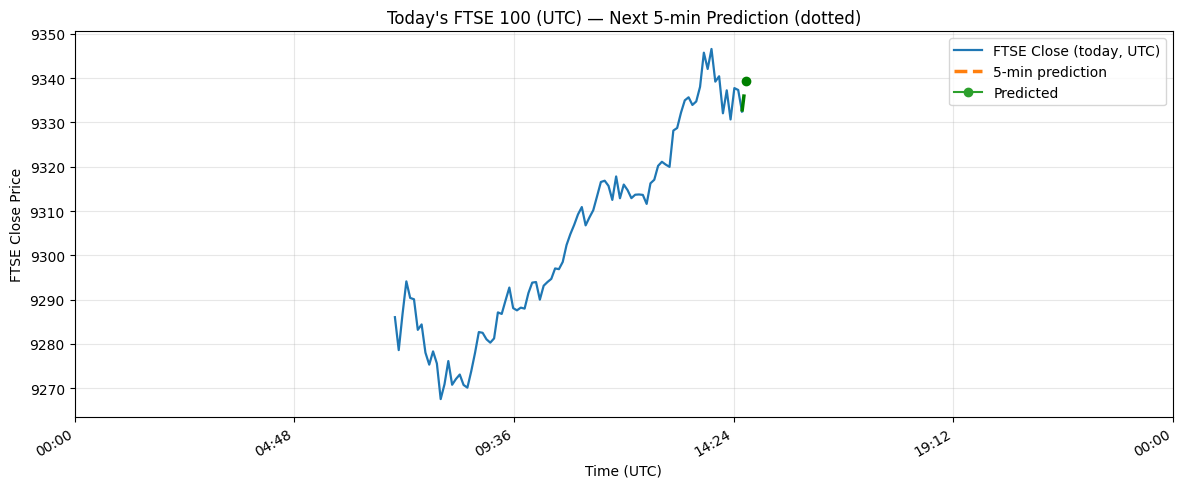

/tmp/ipython-input-3551496706.py:240: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f'Updated at {datetime.utcnow().replace(tzinfo=timezone.utc).isoformat()} UTC — sleeping {int(sleep_seconds)}s until next update...')


Updated at 2025-09-30T14:52:01.499442+00:00 UTC — sleeping 300s until next update...


In [ ]:
# Continuous live updater (single cell) — updates every 5 minutes aligned to 5-min boundaries.
# Paste & run this cell in your notebook. Interrupt kernel to stop.

import time, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta
from IPython.display import clear_output, display

# -------------------------
# Pre-flight checks & setup
# -------------------------
# Use surrogate_model for safety (should exist from training surrogate). If not present, fall back to hybrid model.
use_surrogate = 'surrogate_model' in globals()
if use_surrogate:
    print("Using surrogate_model for continuous predictions.")
else:
    print("surrogate_model not found — will try hybrid model (may fail if QNode issues).")

# Ensure live_df exists (from earlier cells), else fetch recent history
try:
    live_df
except NameError:
    try:
        live_df = fetch_ftse_5m(period='2d')
    except Exception as e:
        raise RuntimeError("Could not fetch FTSE data for live loop: " + str(e))

# Ensure index tz is UTC
if live_df.index.tz is None:
    try:
        live_df.index = live_df.index.tz_localize('Europe/London').tz_convert('UTC')
    except Exception:
        live_df.index = live_df.index.tz_localize('UTC')

# Prepare a persistent figure if not already prepared
try:
    fig, ax, hist_line, pred_line, pred_point
except NameError:
    plt.ioff()
    fig, ax = plt.subplots(figsize=(12,5))
    hist_line, = ax.plot([], [], label="FTSE Close (today, UTC)", linewidth=1.6)
    pred_line, = ax.plot([], [], linestyle='--', linewidth=2.5, label='5-min prediction', zorder=5)
    pred_point, = ax.plot([], [], marker='o', markersize=6, label='Predicted', zorder=6)
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("FTSE Close Price")
    ax.set_title("Today's FTSE 100 (UTC) — Next 5-min Prediction (dotted)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()

# helper: mask for today's UTC indices
def get_today_mask(idx):
    idx_utc = idx.tz_convert('UTC') if idx.tz is not None else idx
    today = datetime.now(timezone.utc).date()
    return np.array([d.date() == today for d in idx_utc])

# helper: safe prediction wrapper that returns float or nan
def predict_next_safe(recent_window, scaler):
    arr = np.asarray(recent_window).reshape(-1)
    scaled = (arr - scaler['min']) / (scaler['max'] - scaler['min'] + 1e-9)
    X = scaled.reshape((1, len(arr), 1))
    try:
        if use_surrogate:
            pred_scaled = surrogate_model.predict(X, verbose=0)
        else:
            pred_scaled = model.predict(X, verbose=0)
        pred_val = float(np.asarray(pred_scaled).flatten()[0])
    except Exception as e:
        print("Prediction call failed:", e)
        pred_val = float('nan')
    # unscale
    if np.isfinite(pred_val):
        return pred_val * (scaler['max'] - scaler['min']) + scaler['min']
    else:
        return float('nan')

# draw helper that always shows a short dashed segment
def update_single_plot(df, pred_ts, pred_val):
    # ensure tz-aware
    if df.index.tz is None:
        try:
            df.index = df.index.tz_localize('Europe/London').tz_convert('UTC')
        except Exception:
            df.index = df.index.tz_localize('UTC')

    # select only today's data
    mask = get_today_mask(df.index)
    today_df = df.iloc[mask]
    if today_df.empty:
        # clear plot and show message
        ax.clear()
        ax.text(0.5,0.5,"No FTSE data for today (UTC) yet — waiting for today's candles...", ha='center', va='center', transform=ax.transAxes)
        ax.set_title("Today's FTSE 100 (UTC) — Next 5-min Prediction (dotted)")
        clear_output(wait=True); display(fig)
        return

    x_dt = today_df.index
    y = today_df['Close'].astype(float).values

    last_time = x_dt[-1]
    last_val = float(y[-1])

    # coerce pred_ts to timezone-aware UTC
    try:
        pred_ts = pd.to_datetime(pred_ts)
        if pred_ts.tz is None:
            pred_ts = pred_ts.tz_localize('UTC')
        else:
            pred_ts = pred_ts.tz_convert('UTC')
    except Exception:
        pred_ts = last_time + timedelta(minutes=5)

    # coerce pred_val
    try:
        pval = float(np.asarray(pred_val).flatten()[0])
    except Exception:
        pval = float(pred_val) if isinstance(pred_val, (float,int)) else float('nan')

    # convert datetimes to matplotlib numeric to avoid dtype/tz mismatch
    x_num = mdates.date2num(x_dt.to_pydatetime())
    last_num = x_num[-1]
    pred_num = mdates.date2num(pred_ts.to_pydatetime())

    # if pred time not ahead, nudge by 1 minute (1/1440 day)
    if not (np.isfinite(pred_num) and pred_num > last_num):
        pred_num = last_num + (1.0 / 1440.0)

    # update history
    hist_line.set_data(x_num, y)

    # update prediction dashed line and point
    if np.isfinite(pval):
        pred_line.set_data([last_num, pred_num], [last_val, pval])
        color = 'green' if pval >= last_val else 'red'
        pred_line.set_color(color)
        pred_line.set_linestyle((0,(5,5)))
        pred_line.set_linewidth(2.5)
        pred_line.set_zorder(10)

        pred_point.set_data([pred_num], [pval])
        pred_point.set_color(color)
        pred_point.set_zorder(11)
        pred_point.set_markersize(6)
    else:
        pred_line.set_data([], [])
        pred_point.set_data([], [])

    # set x-limits to UTC today 00:00 -> 23:59 and format ticks
    now_utc = datetime.now(timezone.utc)
    start_utc = datetime(now_utc.year, now_utc.month, now_utc.day, tzinfo=timezone.utc)
    end_utc = start_utc + timedelta(days=1)
    ax.set_xlim(mdates.date2num(start_utc), mdates.date2num(end_utc))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone.utc))

    # autoscale only y, keep x fixed
    ax.relim()
    ax.autoscale_view(scalex=False, scaley=True)

    # display updated figure in same output cell
    clear_output(wait=True)
    display(fig)

# -------------------------
# Main continuous loop
# -------------------------
print("Starting continuous live updater — will update on 5-minute boundaries. Interrupt kernel to stop.")

try:
    while True:
        # Fetch recent data (2 days) to ensure we get the latest candles
        try:
            latest = fetch_ftse_5m(period='2d')
        except Exception as e:
            print("Data fetch failed:", e)
            time.sleep(60)
            continue

        # append any new rows
        new_rows = latest[~latest.index.isin(live_df.index)]
        if not new_rows.empty:
            live_df = pd.concat([live_df, new_rows]).sort_index()

        # ensure tz-awareness
        if live_df.index.tz is None:
            try:
                live_df.index = live_df.index.tz_localize('Europe/London').tz_convert('UTC')
            except Exception:
                live_df.index = live_df.index.tz_localize('UTC')

        # need at least LOOKBACK values
        if len(live_df) < LOOKBACK:
            print("Not enough data for lookback. Waiting 60s.")
            time.sleep(60)
            continue

        # compute prediction
        recent_window = live_df['Close'].values[-LOOKBACK:]
        pred_ts = live_df.index[-1] + timedelta(minutes=5)
        pred_val = predict_next_safe(recent_window, scaler)

        # write to log
        try:
            last_val = float(live_df['Close'].iloc[-1])
            direction = 'up' if np.isfinite(pred_val) and pred_val >= last_val else ('down' if np.isfinite(pred_val) else 'nan')
            row = {
                'predicted_at_utc': datetime.utcnow().replace(tzinfo=timezone.utc).isoformat(),
                'for_timestamp_utc': str(pred_ts),
                'last_time_utc': str(live_df.index[-1]),
                'last_close': last_val,
                'pred_value': (float(pred_val) if np.isfinite(pred_val) else None),
                'direction': direction
            }
            df_row = pd.DataFrame([row])
            log_path = 'predictions_log.csv'
            if not os.path.exists(log_path):
                df_row.to_csv(log_path, index=False)
            else:
                df_row.to_csv(log_path, mode='a', header=False, index=False)
        except Exception as e:
            print("Warning: logging failed:", e)

        # update same plot (only today's data shown on x-axis)
        update_single_plot(live_df, pred_ts, pred_val)

        # Sleep until the next 5-minute boundary (small buffer)
        now = datetime.now(timezone.utc)
        # seconds into the day
        seconds_now = now.minute*60 + now.second
        next_marks = math.ceil(seconds_now / 300) * 300
        # compute next time as today's midnight + next_marks seconds
        today_midnight = datetime(now.year, now.month, now.day, tzinfo=timezone.utc)
        next_time = today_midnight + timedelta(seconds=next_marks)
        sleep_seconds = (next_time - now).total_seconds() + 2.0
        if sleep_seconds < 0:
            sleep_seconds = 300.0
        print(f'Updated at {datetime.utcnow().replace(tzinfo=timezone.utc).isoformat()} UTC — sleeping {int(sleep_seconds)}s until next update...')
        time.sleep(sleep_seconds)

except KeyboardInterrupt:
    print("Live updater stopped by user. Final plot below.")
    clear_output(wait=True)
    display(fig)


## **BILSTM**

In [ ]:
# Cell: Build hybrid BiLSTM -> classical -> VQC model (robust qnode wrapper)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pennylane as qml
import numpy as np

def build_hybrid_bilstm_model(lookback=LOOKBACK, n_qubits=N_QUBITS, vqc_layers=VQC_LAYERS, horizon=PRED_HORIZON):
    """
    BiLSTM encoder -> classical Dense (2N) -> pad/normalize -> VQC (4 qubits, 3 layers) -> Dense output
    Uses qml.qnn.TFKerasLayer/KerasLayer if available, else falls back to custom tf.keras Layer using tf.map_fn.
    """
    # ---- Classical BiLSTM encoder ----
    inputs = keras.Input(shape=(lookback, 1), name='history_input')
    # Bidirectional LSTM encoder (concatenates forward/backward outputs)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False), name='bilstm_encoder')(inputs)
    # Map to 2N features (paper-like mapping)
    twoN = 2 * n_qubits
    x = layers.Dense(twoN, activation='tanh', name='classical_input_layer')(x)

    # ---- pad & normalize for amplitude embedding ----
    def pad_and_normalize(v):
        batch_size = tf.shape(v)[0]
        target = 2 ** n_qubits
        pad_len = target - twoN
        if pad_len < 0:
            v = tf.keras.layers.Dense(target, activation='tanh')(v)
            pad_len = 0
        if pad_len > 0:
            paddings = tf.zeros((batch_size, pad_len), dtype=v.dtype)
            v = tf.concat([v, paddings], axis=1)
        v_norm = tf.norm(v, axis=1, keepdims=True) + 1e-9
        v = v / v_norm
        return v

    x_prep = layers.Lambda(lambda z: pad_and_normalize(z), name='pad_normalize')(x)

    # ---- Quantum circuit definition ----
    dev = qml.device('default.qubit', wires=n_qubits)

    def quantum_circuit(inputs, weights):
        qml.AmplitudeEmbedding(inputs, wires=list(range(n_qubits)), normalize=True)
        for layer in range(vqc_layers):
            for q in range(n_qubits):
                qml.RX(weights[layer, q, 0], wires=q)
                qml.RY(weights[layer, q, 1], wires=q)
                qml.RZ(weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q+1) % n_qubits])
        exps = [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]
        return qml.math.stack(exps)

    weight_shapes = (vqc_layers, n_qubits, 3)

    # ---- Try to wrap QNode with qml.qnn TFKerasLayer/KerasLayer, else fallback ----
    try:
        qnn_layer_cls = getattr(qml.qnn, 'TFKerasLayer', None) or getattr(qml.qnn, 'KerasLayer', None)
        if qnn_layer_cls is not None:
            qnode = qml.QNode(quantum_circuit, dev, interface='tf', diff_method='backprop')
            qlayer = qnn_layer_cls(qnode, {"weights": weight_shapes}, output_dim=n_qubits)
            q_out = qlayer(x_prep)
        else:
            raise AttributeError("qml.qnn TFKerasLayer/KerasLayer not found")
    except Exception as e:
        print("Warning: falling back to custom QNode Layer (reason: {}).".format(e))
        qnode = qml.QNode(quantum_circuit, dev, interface='tf', diff_method='backprop')

        class QNodeLayer(tf.keras.layers.Layer):
            def __init__(self, qnode, weight_shapes, n_qubits, **kwargs):
                super().__init__(**kwargs)
                self.qnode = qnode
                self.weight_shapes = weight_shapes
                self.n_qubits = n_qubits
                # use add_weight to ensure proper TF variable handling
                self.qweights = self.add_weight(name='vqc_weights',
                                                shape=self.weight_shapes,
                                                initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
                                                trainable=True, dtype=tf.float32)

            def call(self, inputs):
                # inputs shape: (batch, 2**n_qubits)
                inputs = tf.cast(inputs, tf.float32)

                # Call the qnode per sample using tf.map_fn to avoid shape/type issues
                def single_call(x):
                    out = self.qnode(x, self.qweights)
                    return tf.cast(out, tf.float32)

                out = tf.map_fn(single_call, inputs, fn_output_signature=tf.float32)
                return out

            def compute_output_shape(self, input_shape):
                return (input_shape[0], self.n_qubits)

            def get_config(self):
                cfg = super().get_config()
                cfg.update({"weight_shapes": self.weight_shapes, "n_qubits": self.n_qubits})
                return cfg

        qlayer = QNodeLayer(qnode, weight_shapes, n_qubits, name='vqc_custom_layer')
        q_out = qlayer(x_prep)

    # ---- Final classical output mapping ----
    outputs = layers.Dense(horizon, name='output_layer')(q_out)

    model = keras.Model(inputs=inputs, outputs=outputs, name='hybrid_bilstm_qultsf_model')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss='mse', metrics=['mae'])
    return model

# Instantiate and inspect
model_bi = build_hybrid_bilstm_model(lookback=LOOKBACK, n_qubits=N_QUBITS, vqc_layers=VQC_LAYERS)
model_bi.summary()


In [ ]:
# Cell A: (re)build BiLSTM hybrid model if not present
try:
    model_bi
    print("model_bi already exists.")
except NameError:
    model_bi = build_hybrid_bilstm_model(lookback=LOOKBACK, n_qubits=N_QUBITS, vqc_layers=VQC_LAYERS)
    model_bi.summary()


In [ ]:
# Cell B: build encoder submodel from model_bi (input -> pad_normalize output)
from tensorflow.keras import Model

# Ensure pad_normalize exists in this model
try:
    pad_layer = model_bi.get_layer('pad_normalize')
except Exception as e:
    print("pad_normalize layer not found in model_bi. Listing layers:")
    for i, lay in enumerate(model_bi.layers):
        print(i, lay.name)
    raise e

encoder_submodel_bi = Model(inputs=model_bi.input, outputs=pad_layer.output, name='encoder_submodel_bi')
encoder_submodel_bi.summary()


Model: "encoder_submodel_bi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ history_input (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_encoder (Bidirectional)  │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classical_input_layer (Dense)   │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pad_normalize (Lambda)          │ (None, 16)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,824 (136.03 KB)

 Trainable params: 34,824 (136.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell C: build surrogate_model_bi (encoder output -> prediction)
import tensorflow as tf
from tensorflow.keras import layers as klayers

surrogate_input = tf.keras.Input(shape=(LOOKBACK, 1), name='surrogate_input_bi')
encoded_bi = encoder_submodel_bi(surrogate_input)   # shape (batch, 2**N_QUBITS)
surrogate_out = klayers.Dense(PRED_HORIZON, name='surrogate_output_bi')(encoded_bi)

surrogate_model_bi = tf.keras.Model(inputs=surrogate_input, outputs=surrogate_out, name='surrogate_model_bi')
surrogate_model_bi.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss='mse', metrics=['mae'])
surrogate_model_bi.summary()


Model: "surrogate_model_bi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ surrogate_input_bi (InputLayer) │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_submodel_bi             │ (None, 16)             │        34,824 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ surrogate_output_bi (Dense)     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,841 (136.10 KB)

 Trainable params: 34,841 (136.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell D: train the surrogate_model_bi (run this cell to train)
# prepare data if not already prepared (uses df from earlier fetch cell)
try:
    df  # from Cell 6 earlier
except NameError:
    df = fetch_ftse_5m(period=HIST_PERIOD)

series = df['Close'].values
scaler = fit_scaler(series)
scaled = scale_array(series, scaler)

X_all, y_all = create_windows(scaled, lookback=LOOKBACK, horizon=PRED_HORIZON)
X_all = X_all.reshape((-1, LOOKBACK, 1))
y_all = y_all.reshape((-1, PRED_HORIZON))

# train/val split
n_train = int(0.8 * len(X_all))
X_train_bi, X_val_bi = X_all[:n_train], X_all[n_train:]
y_train_bi, y_val_bi = y_all[:n_train], y_all[n_train:]

# Train surrogate (you can modify EPOCHS here)
EPOCHS_SUR = 20
history_bi = surrogate_model_bi.fit(X_train_bi, y_train_bi, validation_data=(X_val_bi, y_val_bi),
                                    epochs=EPOCHS_SUR, batch_size=BATCH_SIZE, verbose=2)

# Save surrogate
surrogate_model_bi.save('surrogate_model_bi.h5')
print("Saved surrogate_model_bi.h5")


Epoch 1/20
18/18 - 5s - 282ms/step - loss: 0.0488 - mae: 0.1697 - val_loss: 0.0079 - val_mae: 0.0711
Epoch 2/20
18/18 - 0s - 17ms/step - loss: 0.0162 - mae: 0.0993 - val_loss: 0.0076 - val_mae: 0.0647
Epoch 3/20
18/18 - 0s - 16ms/step - loss: 0.0101 - mae: 0.0806 - val_loss: 0.0054 - val_mae: 0.0567
Epoch 4/20
18/18 - 0s - 18ms/step - loss: 0.0064 - mae: 0.0649 - val_loss: 0.0041 - val_mae: 0.0502
Epoch 5/20
18/18 - 0s - 16ms/step - loss: 0.0042 - mae: 0.0533 - val_loss: 0.0032 - val_mae: 0.0451
Epoch 6/20
18/18 - 0s - 17ms/step - loss: 0.0031 - mae: 0.0442 - val_loss: 0.0026 - val_mae: 0.0410
Epoch 7/20
18/18 - 0s - 17ms/step - loss: 0.0025 - mae: 0.0389 - val_loss: 0.0023 - val_mae: 0.0380
Epoch 8/20
18/18 - 0s - 16ms/step - loss: 0.0022 - mae: 0.0364 - val_loss: 0.0021 - val_mae: 0.0358
Epoch 9/20
18/18 - 0s - 17ms/step - loss: 0.0020 - mae: 0.0346 - val_loss: 0.0019 - val_mae: 0.0337
Epoch 10/20
18/18 - 0s - 16ms/step - loss: 0.0018 - mae: 0.0331 - val_loss: 0.0017 - val_mae: 0.031

Saved surrogate_model_bi.h5


In [ ]:
# Cell E: prediction helper for BiLSTM surrogate
import numpy as np

def predict_next_live_bi(recent_window, scaler):
    """
    recent_window: 1D raw close prices (length LOOKBACK)
    returns: raw predicted price (float) or nan
    """
    arr = np.asarray(recent_window).reshape(-1)
    scaled = (arr - scaler['min']) / (scaler['max'] - scaler['min'] + 1e-9)
    X = scaled.reshape((1, len(arr), 1))
    try:
        pred_scaled = surrogate_model_bi.predict(X, verbose=0)
        pred_scaled_val = float(np.asarray(pred_scaled).flatten()[0])
    except Exception as e:
        print("Surrogate predict failed:", e)
        pred_scaled_val = float('nan')
    if np.isfinite(pred_scaled_val):
        return pred_scaled_val * (scaler['max'] - scaler['min']) + scaler['min']
    else:
        return float('nan')


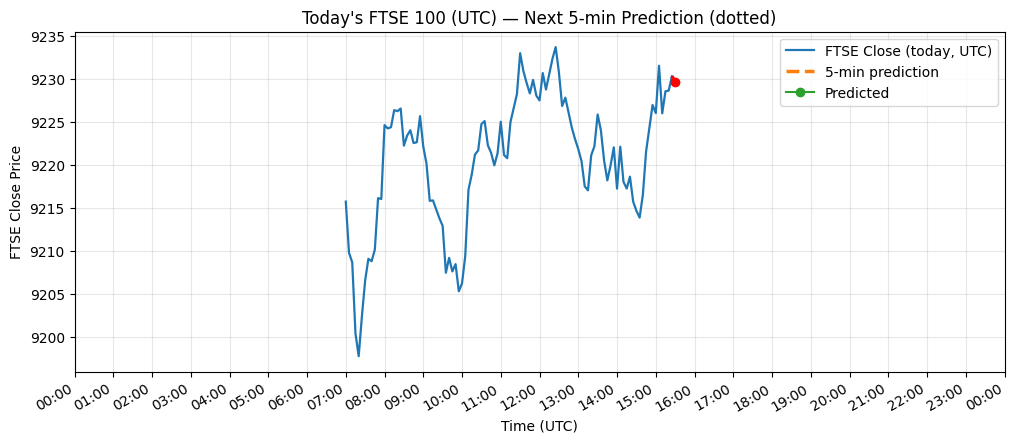

In [ ]:
# Cell F: Live updater (single in-place figure) using BiLSTM surrogate
import time, math, os
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
from IPython.display import clear_output, display

# Ensure surrogate_model_bi is present
if 'surrogate_model_bi' not in globals():
    raise RuntimeError("surrogate_model_bi not found. Run Cells B-C-D first.")

# Prepare live_df if missing
try:
    live_df
except NameError:
    live_df = fetch_ftse_5m(period='2d')

# Ensure tz-aware UTC index
if live_df.index.tz is None:
    try:
        live_df.index = live_df.index.tz_localize('Europe/London').tz_convert('UTC')
    except Exception:
        live_df.index = live_df.index.tz_localize('UTC')

# Setup persistent fig if not already
try:
    fig, ax, hist_line, pred_line, pred_point
except NameError:
    plt.ioff()
    fig, ax = plt.subplots(figsize=(12,5))
    hist_line, = ax.plot([], [], label='FTSE Close (today, UTC)', linewidth=1.6)
    pred_line, = ax.plot([], [], linestyle='--', linewidth=2.5, label='5-min prediction', zorder=5)
    pred_point, = ax.plot([], [], marker='o', markersize=6, label='Predicted', zorder=6)
    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel('FTSE Close Price')
    ax.set_title("Today's FTSE 100 (UTC) — Next 5-min Prediction (BiLSTM surrogate)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()

def get_today_mask(idx):
    idx_utc = idx.tz_convert('UTC') if idx.tz is not None else idx
    today = datetime.now(timezone.utc).date()
    return np.array([d.date() == today for d in idx_utc])

def update_plot_bi(df, pred_ts, pred_val):
    # draw only today's data and dotted pred (always nudge if necessary)
    if df.index.tz is None:
        try:
            df.index = df.index.tz_localize('UTC')
        except Exception:
            pass

    mask = get_today_mask(df.index)
    today_df = df.iloc[mask]
    if today_df.empty:
        ax.clear()
        ax.text(0.5, 0.5, "No FTSE today (UTC) data yet.", ha='center', va='center', transform=ax.transAxes)
        clear_output(wait=True); display(fig)
        return

    x_dt = today_df.index
    y = today_df['Close'].astype(float).values
    last_time = x_dt[-1]; last_val = float(y[-1])

    # coerce pred_ts tz-aware and pred_val float
    try:
        pred_ts = pd.to_datetime(pred_ts)
        if pred_ts.tz is None:
            pred_ts = pred_ts.tz_localize('UTC')
        else:
            pred_ts = pred_ts.tz_convert('UTC')
    except Exception:
        pred_ts = last_time + timedelta(minutes=5)
    try:
        pval = float(np.asarray(pred_val).flatten()[0])
    except Exception:
        pval = float(pred_val) if isinstance(pred_val, (float,int)) else float('nan')

    # numeric conversion for plotting
    x_num = mdates.date2num(x_dt.to_pydatetime())
    last_num = x_num[-1]; pred_num = mdates.date2num(pred_ts.to_pydatetime())
    if not (np.isfinite(pred_num) and pred_num > last_num):
        pred_num = last_num + (1.0/1440.0)  # nudge 1 minute

    hist_line.set_data(x_num, y)
    if np.isfinite(pval):
        pred_line.set_data([last_num, pred_num], [last_val, pval])
        color = 'green' if pval >= last_val else 'red'
        pred_line.set_color(color); pred_line.set_linestyle((0,(5,5)))
        pred_point.set_data([pred_num], [pval]); pred_point.set_color(color)
    else:
        pred_line.set_data([], []); pred_point.set_data([], [])

    # x-limits today
    now_utc = datetime.now(timezone.utc)
    start_utc = datetime(now_utc.year, now_utc.month, now_utc.day, tzinfo=timezone.utc)
    end_utc = start_utc + timedelta(days=1)
    ax.set_xlim(mdates.date2num(start_utc), mdates.date2num(end_utc))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone.utc))

    ax.relim(); ax.autoscale_view(scalex=False, scaley=True)
    clear_output(wait=True); display(fig)

# Continuous update loop (aligned to 5-min boundaries)
print("Starting BiLSTM surrogate live updater. Interrupt kernel to stop.")
try:
    while True:
        try:
            latest = fetch_ftse_5m(period='2d')
        except Exception as e:
            print("Fetch failed:", e); time.sleep(60); continue

        new_rows = latest[~latest.index.isin(live_df.index)]
        if not new_rows.empty:
            live_df = pd.concat([live_df, new_rows]).sort_index()

        if live_df.index.tz is None:
            try:
                live_df.index = live_df.index.tz_localize('Europe/London').tz_convert('UTC')
            except Exception:
                live_df.index = live_df.index.tz_localize('UTC')

        if len(live_df) < LOOKBACK:
            print("Not enough data for LOOKBACK. Waiting 60s."); time.sleep(60); continue

        recent = live_df['Close'].values[-LOOKBACK:]
        pred_ts = live_df.index[-1] + timedelta(minutes=5)
        pred_val = predict_next_live_bi(recent, scaler)

        # log entry
        try:
            last_val = float(live_df['Close'].iloc[-1])
            direction = 'up' if np.isfinite(pred_val) and pred_val >= last_val else ('down' if np.isfinite(pred_val) else 'nan')
            row = {'predicted_at_utc': datetime.utcnow().replace(tzinfo=timezone.utc).isoformat(),
                   'for_timestamp_utc': str(pred_ts),
                   'last_time_utc': str(live_df.index[-1]),
                   'last_close': last_val,
                   'pred_value': (float(pred_val) if np.isfinite(pred_val) else None),
                   'direction': direction}
            df_row = pd.DataFrame([row])
            log_path='predictions_log_bi.csv'
            if not os.path.exists(log_path):
                df_row.to_csv(log_path, index=False)
            else:
                df_row.to_csv(log_path, mode='a', header=False, index=False)
        except Exception as e:
            print("Logging failed:", e)

        update_plot_bi(live_df, pred_ts, pred_val)
        print(f'Updated at {datetime.utcnow().replace(tzinfo=timezone.utc).isoformat()} UTC; next check in ~5min.')

        # sleep to next 5-min boundary
        now = datetime.now(timezone.utc)
        seconds_now = now.minute*60 + now.second
        next_marks = math.ceil(seconds_now / 300) * 300
        today_midnight = datetime(now.year, now.month, now.day, tzinfo=timezone.utc)
        next_time = today_midnight + timedelta(seconds=next_marks)
        sleep_seconds = (next_time - now).total_seconds() + 2.0
        if sleep_seconds < 0:
            sleep_seconds = 300.0
        time.sleep(sleep_seconds)

except KeyboardInterrupt:
    print("Stopped by user. Final plot:")
    clear_output(wait=True); display(fig)


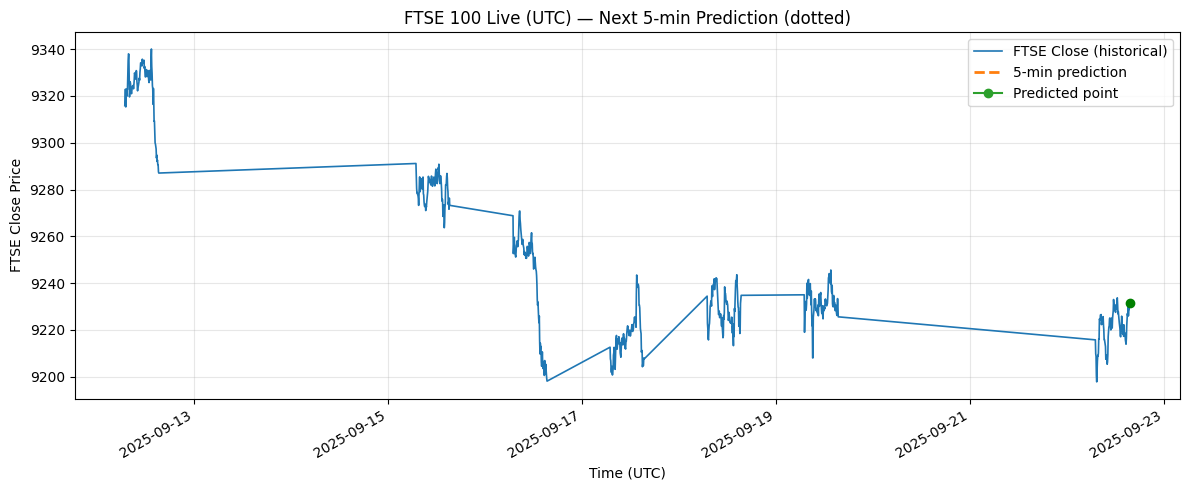

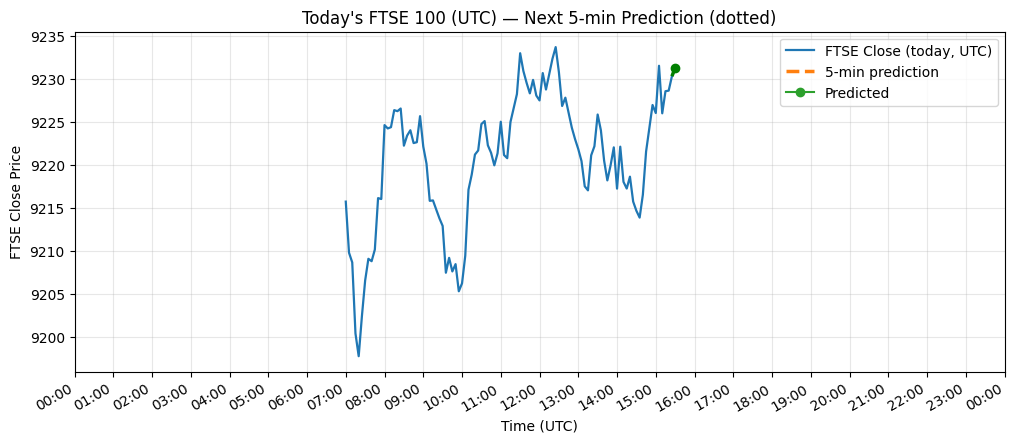

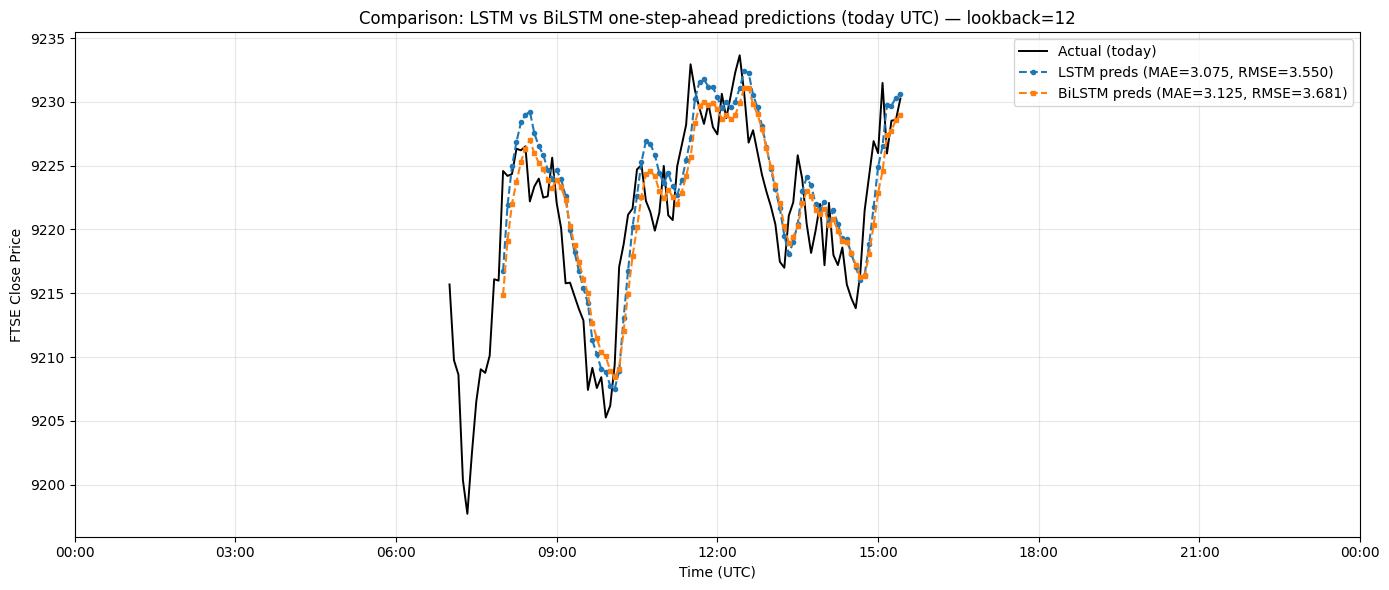

,model,MAE,RMSE,pred_count
0,LSTM surrogate,3.075277,3.550356,90
1,BiLSTM surrogate,3.124835,3.680714,90


In [ ]:
# Comparison: LSTM-surrogate vs BiLSTM-surrogate on today's FTSE (UTC)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# ---------- Preconditions ----------
if 'surrogate_model' not in globals():
    raise RuntimeError("surrogate_model (LSTM surrogate) not found. Create/train it first (see earlier cells).")
if 'surrogate_model_bi' not in globals():
    raise RuntimeError("surrogate_model_bi (BiLSTM surrogate) not found. Create/train it first (see earlier cells).")
if 'live_df' not in globals():
    raise RuntimeError("live_df not found (the FTSE data). Run data fetch cell first.")

# Ensure index tz-aware UTC
if live_df.index.tz is None:
    try:
        live_df.index = live_df.index.tz_localize('Europe/London').tz_convert('UTC')
    except Exception:
        live_df.index = live_df.index.tz_localize('UTC')

# Filter to today's UTC data
today = datetime.now(timezone.utc).date()
idx_utc = live_df.index.tz_convert('UTC') if live_df.index.tz is not None else live_df.index
mask_today = np.array([d.date() == today for d in idx_utc])
today_df = live_df.iloc[mask_today].copy()

if len(today_df) < LOOKBACK + 2:
    raise RuntimeError(f"Not enough today's data to compute rolling predictions. Need at least LOOKBACK+2 ({LOOKBACK+2}), but got {len(today_df)}")

values = today_df['Close'].astype(float).values
times = today_df.index.to_pydatetime()  # timezone-aware datetimes

# ---------- Rolling one-step-ahead predictions ----------
def rolling_predictions(surrogate_model_local, series_values, scaler_local, lookback):
    preds = []
    pred_times = []
    # For i = lookback .. len(series)-1, window series[i-lookback:i] -> predict value at index i
    for i in range(lookback, len(series_values)):
        window = series_values[i-lookback:i]
        scaled = (np.asarray(window) - scaler_local['min']) / (scaler_local['max'] - scaler_local['min'] + 1e-9)
        X = scaled.reshape((1, lookback, 1))
        try:
            pred_scaled = surrogate_model_local.predict(X, verbose=0)
            pred_scaled_val = float(np.asarray(pred_scaled).flatten()[0])
            pred_raw = pred_scaled_val * (scaler_local['max'] - scaler_local['min']) + scaler_local['min']
        except Exception as e:
            # on failure, use NaN
            pred_raw = float('nan')
        preds.append(pred_raw)
        pred_times.append(times[i])  # predicted value corresponds to time index i
    return np.array(pred_times), np.array(preds)

# Compute LSTM and BiLSTM rolling predictions
l_times, l_preds = rolling_predictions(surrogate_model, values, scaler, LOOKBACK)
bi_times, bi_preds = rolling_predictions(surrogate_model_bi, values, scaler, LOOKBACK)

# Align actuals to predicted times: actuals at indices LOOKBACK..end-1
actuals = values[LOOKBACK:]

# Compute error metrics (drop NaNs)
def metrics_for(preds_arr, actuals_arr):
    mask = np.isfinite(preds_arr)
    if mask.sum() == 0:
        return float('nan'), float('nan')
    mae = mean_absolute_error(actuals_arr[mask], preds_arr[mask])
    rmse = math.sqrt(mean_squared_error(actuals_arr[mask], preds_arr[mask]))
    return mae, rmse

l_mae, l_rmse = metrics_for(l_preds, actuals)
bi_mae, bi_rmse = metrics_for(bi_preds, actuals)

# ---------- Plotting ----------
plt.figure(figsize=(14,6))
ax = plt.gca()

# Plot actual today series
ax.plot(times, values, color='black', linewidth=1.4, label='Actual (today)')

# Plot LSTM preds as dashed blue (connect predicted points)
if np.any(np.isfinite(l_preds)):
    ax.plot(l_times, l_preds, linestyle='--', marker='o', markersize=3, color='tab:blue',
            label=f'LSTM preds (MAE={l_mae:.3f}, RMSE={l_rmse:.3f})')
else:
    ax.plot([], [], linestyle='--', marker='o', markersize=3, color='tab:blue',
            label='LSTM preds (no valid preds)')

# Plot BiLSTM preds as dashed orange
if np.any(np.isfinite(bi_preds)):
    ax.plot(bi_times, bi_preds, linestyle='--', marker='s', markersize=3, color='tab:orange',
            label=f'BiLSTM preds (MAE={bi_mae:.3f}, RMSE={bi_rmse:.3f})')
else:
    ax.plot([], [], linestyle='--', marker='s', markersize=3, color='tab:orange',
            label='BiLSTM preds (no valid preds)')

# Format x-axis as UTC HH:MM and limit to today
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone.utc))
start_utc = datetime(today.year, today.month, today.day, tzinfo=timezone.utc)
end_utc = start_utc + timedelta(days=1)
ax.set_xlim(start_utc, end_utc)

ax.set_xlabel('Time (UTC)')
ax.set_ylabel('FTSE Close Price')
ax.set_title(f"Comparison: LSTM vs BiLSTM one-step-ahead predictions (today UTC) — lookback={LOOKBACK}")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ---------- Show small metrics table below plot ----------
metrics_df = pd.DataFrame({
    'model': ['LSTM surrogate', 'BiLSTM surrogate'],
    'MAE': [l_mae, bi_mae],
    'RMSE': [l_rmse, bi_rmse],
    'pred_count': [np.isfinite(l_preds).sum(), np.isfinite(bi_preds).sum()]
})
display(metrics_df)
